In [48]:
# from pathlib import Path

# dire = Path("../../../Datasets_for_my_practice/agricultural_crops/Agricultural-crops/")

# print(dire.)

In [49]:
from pathlib import Path

DATASET_PATH = Path("../../../Datasets_for_my_practice/agricultural_crops/")

print("=" * 60)

for split in DATASET_PATH.iterdir():

    if split.is_dir():

        print(f"\n📂 {split.name}")

        for cls in split.iterdir():

            if cls.is_dir():

                num_images = len(list(cls.glob("*")))

                print(f"   ├── {cls.name:<20} {num_images} images")

print("\n" + "=" * 60)


📂 Agricultural-crops
   ├── almond               21 images
   ├── banana               31 images
   ├── cardamom             22 images
   ├── Cherry               32 images
   ├── chilli               23 images
   ├── clove                30 images
   ├── coconut              25 images
   ├── Coffee-plant         29 images
   ├── cotton               32 images
   ├── Cucumber             31 images
   ├── Fox_nut(Makhana)     23 images
   ├── gram                 25 images
   ├── jowar                30 images
   ├── jute                 23 images
   ├── Lemon                28 images
   ├── maize                31 images
   ├── mustard-oil          28 images
   ├── Olive-tree           30 images
   ├── papaya               23 images
   ├── Pearl_millet(bajra)  39 images
   ├── pineapple            25 images
   ├── rice                 29 images
   ├── soyabean             30 images
   ├── sugarcane            25 images
   ├── sunflower            24 images
   ├── tea                  

In [58]:
import torchvision
from torchvision import transforms
from torchvision.models import EfficientNet_B0_Weights

weights = EfficientNet_B0_Weights.DEFAULT

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    weights.transforms()
])

valid_transform = weights.transforms()


In [51]:
print(weights.transforms())

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)


In [52]:
import random
import shutil
from pathlib import Path

src_dir = Path("../../../Datasets_for_my_practice/agricultural_crops/Agricultural-crops")
dest_dir = Path("../../../Datasets_for_my_practice/agricultural_crops/dataset")

train_ratio = 0.7
valid_ratio = 0.15
test_ratio = 0.15

random.seed(42)

In [53]:
dest_dir.mkdir(parents=True, exist_ok=True)

print("Source File: ",src_dir.exists())
print("Destination File: ",dest_dir.exists())

Source File:  True
Destination File:  True


In [54]:

classes = sorted(folder.name for folder in src_dir.iterdir() if folder.is_dir())
print(classes)

['Cherry', 'Coffee-plant', 'Cucumber', 'Fox_nut(Makhana)', 'Lemon', 'Olive-tree', 'Pearl_millet(bajra)', 'Tobacco-plant', 'almond', 'banana', 'cardamom', 'chilli', 'clove', 'coconut', 'cotton', 'gram', 'jowar', 'jute', 'maize', 'mustard-oil', 'papaya', 'pineapple', 'rice', 'soyabean', 'sugarcane', 'sunflower', 'tea', 'tomato', 'vigna-radiati(Mung)', 'wheat']


In [55]:
if dest_dir.exists():
    shutil.rmtree(dest_dir)
    
for split in ["train", "valid", "test"]:
    for cls in classes:
        (dest_dir / split / cls).mkdir(parents=True, exist_ok=True) 
        
print("Dataset Folder Structure is ready")

Dataset Folder Structure is ready


In [56]:
# for cls in original_class_name:
#     img_paths = [img for img in (src_dir / cls).iterdir() if img.suffix.lower() in img_extention]

In [57]:
from PIL import Image

img_extention = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

for cls in classes:
    img_paths = [img for img in (src_dir / cls).iterdir() if img.suffix.lower() in img_extention]
    
    random.shuffle(img_paths)
    
    total_img = len(img_paths)
    
    train_end = int(total_img*train_ratio)
    valid_end = train_end + int(total_img*valid_ratio)
    
    split = {
        "train" : img_paths[:train_end],
        "valid" : img_paths[train_end: valid_end],
        "test"  : img_paths[valid_end:]
    }
    
    count = 0
    for split_name, files in split.items():
        for img_path in files:
            try:
                with Image.open(img_path) as img:
                    img.verify()
                    
                shutil.copy(
                    img_path,
                    dest_dir / split_name / cls / img_path.name
                )
            
            except Exception:
                count +=1
                print("skipped corrupted image: ", img_path)
                
                                
print("Total skipped corrupted image: ", count)            

print("Dataset Ready 👍")            
                

Total skipped corrupted image:  0
Dataset Ready 👍


In [60]:
from torchvision import datasets

train_dataset = datasets.ImageFolder(
    root= dest_dir / "train",
    transform= train_transform
)

valid_dataset = datasets.ImageFolder(
    root= dest_dir / "valid",
    transform= valid_transform
)

test_dataset = datasets.ImageFolder(
    root= dest_dir / "test",
    transform= valid_transform
)

In [61]:
print("Train Dataset: ", len(train_dataset))
print("Valid Dataset: ", len(valid_dataset))
print("Test Dataset: ", len(test_dataset))

print("Train Classes: ", train_dataset.classes)
print("Train Dataset Labels : ", train_dataset.class_to_idx)

Train Dataset:  569
Valid Dataset:  108
Test Dataset:  152
Train Classes:  ['Cherry', 'Coffee-plant', 'Cucumber', 'Fox_nut(Makhana)', 'Lemon', 'Olive-tree', 'Pearl_millet(bajra)', 'Tobacco-plant', 'almond', 'banana', 'cardamom', 'chilli', 'clove', 'coconut', 'cotton', 'gram', 'jowar', 'jute', 'maize', 'mustard-oil', 'papaya', 'pineapple', 'rice', 'soyabean', 'sugarcane', 'sunflower', 'tea', 'tomato', 'vigna-radiati(Mung)', 'wheat']
Train Dataset Labels :  {'Cherry': 0, 'Coffee-plant': 1, 'Cucumber': 2, 'Fox_nut(Makhana)': 3, 'Lemon': 4, 'Olive-tree': 5, 'Pearl_millet(bajra)': 6, 'Tobacco-plant': 7, 'almond': 8, 'banana': 9, 'cardamom': 10, 'chilli': 11, 'clove': 12, 'coconut': 13, 'cotton': 14, 'gram': 15, 'jowar': 16, 'jute': 17, 'maize': 18, 'mustard-oil': 19, 'papaya': 20, 'pineapple': 21, 'rice': 22, 'soyabean': 23, 'sugarcane': 24, 'sunflower': 25, 'tea': 26, 'tomato': 27, 'vigna-radiati(Mung)': 28, 'wheat': 29}


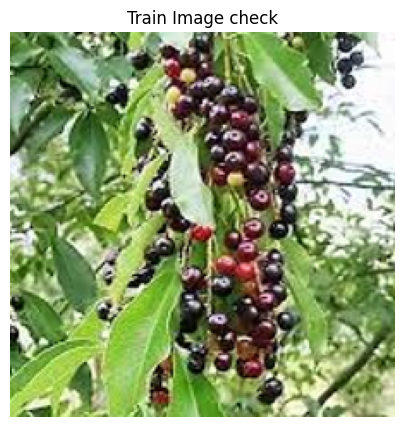

In [62]:
import matplotlib.pyplot as plt
import torch

image, label = train_dataset[0]

preprocess = weights.transforms()

mean = torch.tensor(preprocess.mean).view(3,1,1)
std = torch.tensor(preprocess.std).view(3,1,1)

image = image * std + mean

image = image.permute(1,2,0)

image = image.clamp(0,1)

plt.figure(figsize=[5,5])
plt.imshow(image)
plt.title("Train Image check")
plt.axis("off")
plt.show()

In [63]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [64]:
print("Train batches :", len(train_loader))
print("Valid batches :", len(valid_loader))
print("Test batches  :", len(test_loader))

Train batches : 18
Valid batches : 4
Test batches  : 5


In [65]:
images, labels = next(iter(train_loader))

print("Images Shape :", images.shape)
print("Labels Shape :", labels.shape)

print("Image dtype :", images.dtype)
print("Labels dtype:", labels.dtype)

Images Shape : torch.Size([32, 3, 224, 224])
Labels Shape : torch.Size([32])
Image dtype : torch.float32
Labels dtype: torch.int64


In [67]:
import torch.nn as nn
from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0

weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(weights= weights)
print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [68]:
num_classes = len(train_dataset.classes)

model.classifier[1] = nn.Linear(
    in_features=model.classifier[1].in_features,
    out_features=num_classes
)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=30, bias=True)
)


In [69]:
# Freeze all pretrained layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze only the final classifier
for param in model.classifier[1].parameters():
    param.requires_grad = True

In [70]:
for name, param in model.named_parameters():
    print(f"{name:40} Trainable: {param.requires_grad}")

features.0.0.weight                      Trainable: False
features.0.1.weight                      Trainable: False
features.0.1.bias                        Trainable: False
features.1.0.block.0.0.weight            Trainable: False
features.1.0.block.0.1.weight            Trainable: False
features.1.0.block.0.1.bias              Trainable: False
features.1.0.block.1.fc1.weight          Trainable: False
features.1.0.block.1.fc1.bias            Trainable: False
features.1.0.block.1.fc2.weight          Trainable: False
features.1.0.block.1.fc2.bias            Trainable: False
features.1.0.block.2.0.weight            Trainable: False
features.1.0.block.2.1.weight            Trainable: False
features.1.0.block.2.1.bias              Trainable: False
features.2.0.block.0.0.weight            Trainable: False
features.2.0.block.0.1.weight            Trainable: False
features.2.0.block.0.1.bias              Trainable: False
features.2.0.block.1.0.weight            Trainable: False
features.2.0.b

In [71]:
import torch
import torch.optim as optim

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to device
model = model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer (only trainable parameters)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

print("Device:", device)
print("Loss Function:", criterion)
print("Optimizer:", optimizer)

Device: cuda
Loss Function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [88]:
NUM_EPOCH = 10

train_losses = []
training_accuracies = []

valid_losses = []
valid_accuracies = []

best_valid_acc = 0.0

for epoch in range(NUM_EPOCH):
    
    print(f'Epoch: [{epoch+1} / {NUM_EPOCH}]')
    print("-"*40)
    
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        
        loss = criterion(outputs, labels)
        
        loss.backward()
        
        optimizer.step()
        
        running_loss += loss.item()
        
        _, predict = torch.max(outputs, 1)
        
        total += labels.size(0)
        
        correct += (predict == labels).sum().item()
        
        
    train_loss = running_loss / len(train_loader)
    train_acc = 100*correct/ total
    
    train_losses.append(train_loss)
    training_accuracies.append(train_acc)
    
    ############################
    # Validation Part
    ############################
    
    model.eval()
    
    running_val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in valid_loader:
            
            images = images.to(device)
            labels = labels.to(device)
            
            
            outputs = model(images)
            
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item()
            
            _, predict = torch.max(outputs, 1)
            
            total += labels.size(0)
            
            correct += (predict == labels).sum().item()
        
        
    valid_loss = running_loss / len(valid_loader)
    valid_acc = 100*correct/ total
    
    valid_losses.append(valid_loss)
    valid_accuracies.append(valid_acc)
    
    
    ####################################
    # Save Best Model
    ####################################
    if valid_acc > best_valid_acc:

        best_valid_acc = valid_acc

        # 1. Save checkpoint (resume training)
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_acc": best_valid_acc,
        }, "best_checkpoint.pth")

        # 2. Save entire model (easy inference)
        torch.save(model, "best_model.pth")
        

    ####################################
    # Print Results
    ####################################
    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}%"
    )

    print(
        f"Val Loss:   {valid_loss:.4f} | "
        f"Val Acc:   {valid_acc:.2f}%"
    )

print("\nTraining Finished!")
print(f"Best Validation Accuracy: {best_valid_acc:.2f}%")
        

Epoch: [1 / 10]
----------------------------------------
Train Loss: 0.1452 | Train Acc: 99.82%
Val Loss:   0.6535 | Val Acc:   75.00%
Epoch: [2 / 10]
----------------------------------------
Train Loss: 0.1381 | Train Acc: 99.47%
Val Loss:   0.6216 | Val Acc:   75.93%
Epoch: [3 / 10]
----------------------------------------
Train Loss: 0.1189 | Train Acc: 100.00%
Val Loss:   0.5351 | Val Acc:   75.93%
Epoch: [4 / 10]
----------------------------------------
Train Loss: 0.1164 | Train Acc: 99.47%
Val Loss:   0.5238 | Val Acc:   75.93%
Epoch: [5 / 10]
----------------------------------------
Train Loss: 0.1201 | Train Acc: 99.47%
Val Loss:   0.5402 | Val Acc:   75.93%
Epoch: [6 / 10]
----------------------------------------
Train Loss: 0.1112 | Train Acc: 99.82%
Val Loss:   0.5004 | Val Acc:   75.00%
Epoch: [7 / 10]
----------------------------------------
Train Loss: 0.1060 | Train Acc: 99.65%
Val Loss:   0.4772 | Val Acc:   77.78%
Epoch: [8 / 10]
--------------------------------------

In [92]:
model = torch.load(
    "best_model.pth",
    map_location=device,
    weights_only=False
)

model = model.to(device)
model.eval()

print("✅ Model loaded successfully!")

✅ Model loaded successfully!


In [93]:
# Test Evaluation

model.eval()

test_loss = 0.0
correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Store predictions for later evaluation
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss /= len(test_loader)
test_accuracy = 100 * correct / total

print("=" * 50)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.2f}%")
print("=" * 50)

Test Loss     : 0.7976
Test Accuracy : 77.63%


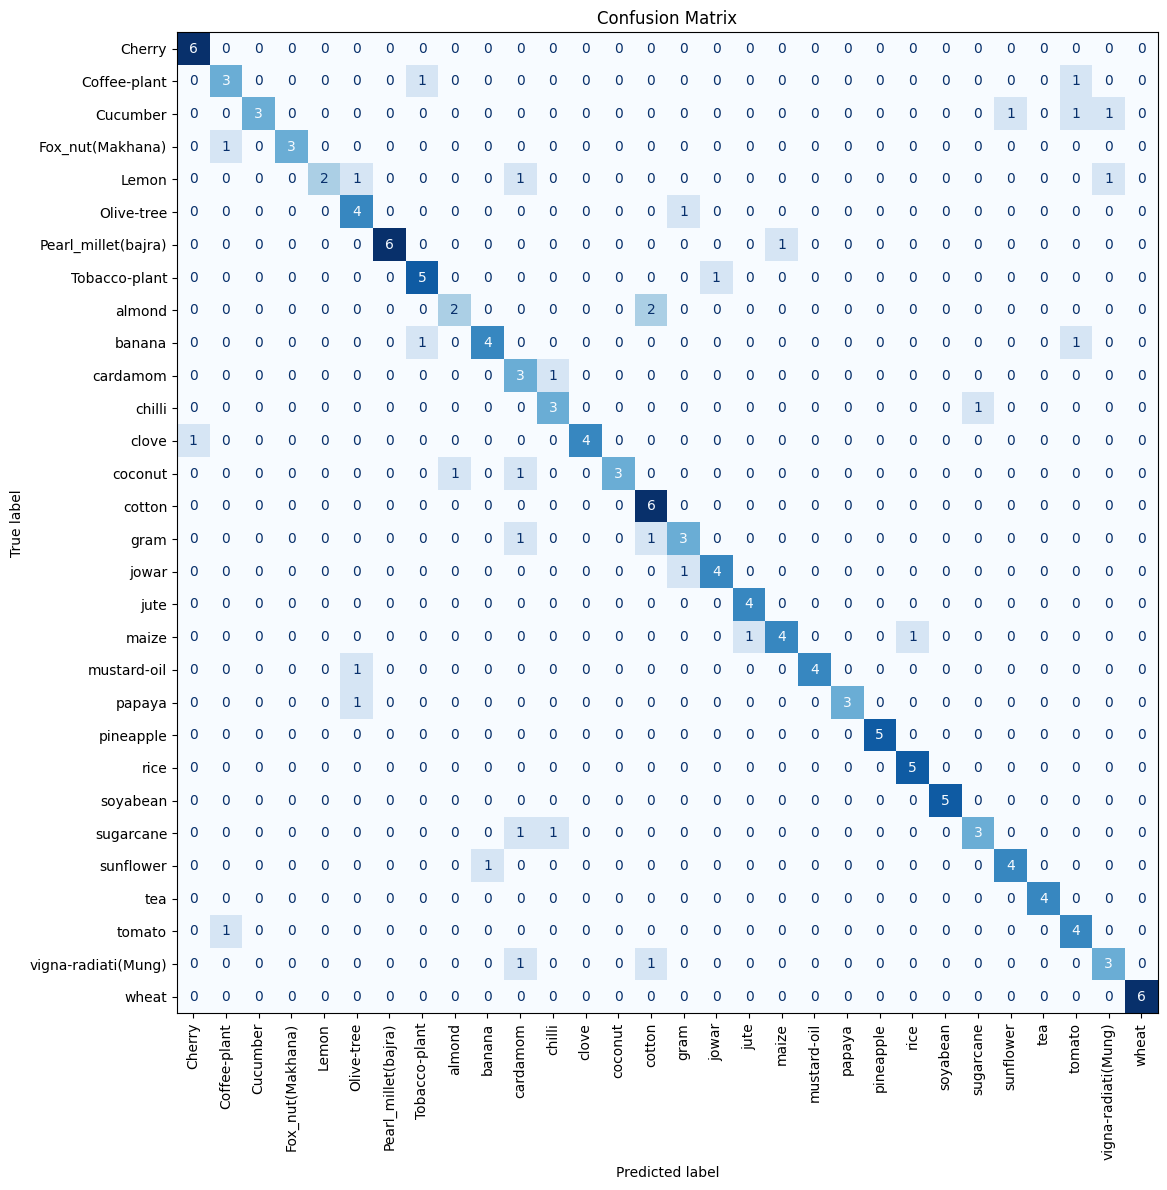

In [94]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Class names
class_names = test_dataset.classes

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(12, 12))

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

# Rotate x-axis labels
plt.xticks(rotation=90)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [95]:
from sklearn.metrics import classification_report

# Get class names
class_names = test_dataset.classes

print("=" * 60)
print("Classification Report")
print("=" * 60)

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)

Classification Report
                     precision    recall  f1-score   support

             Cherry     0.8571    1.0000    0.9231         6
       Coffee-plant     0.6000    0.6000    0.6000         5
           Cucumber     1.0000    0.5000    0.6667         6
   Fox_nut(Makhana)     1.0000    0.7500    0.8571         4
              Lemon     1.0000    0.4000    0.5714         5
         Olive-tree     0.5714    0.8000    0.6667         5
Pearl_millet(bajra)     1.0000    0.8571    0.9231         7
      Tobacco-plant     0.7143    0.8333    0.7692         6
             almond     0.6667    0.5000    0.5714         4
             banana     0.8000    0.6667    0.7273         6
           cardamom     0.3750    0.7500    0.5000         4
             chilli     0.6000    0.7500    0.6667         4
              clove     1.0000    0.8000    0.8889         5
            coconut     1.0000    0.6000    0.7500         5
             cotton     0.6000    1.0000    0.7500         6
 

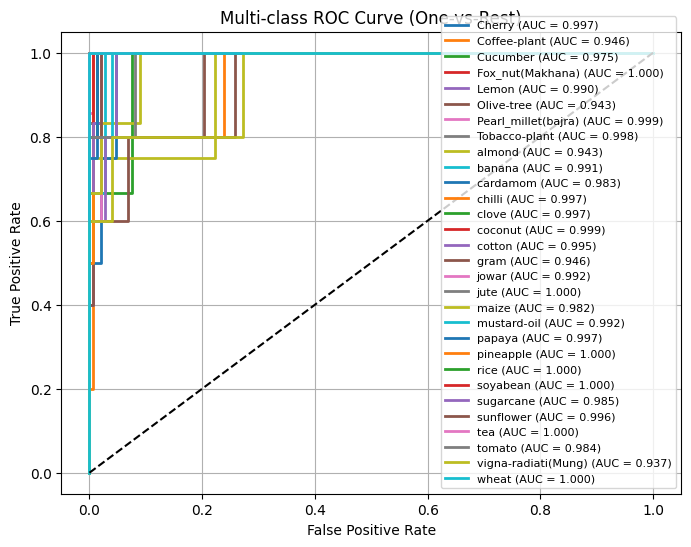

In [96]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import numpy as np

# Evaluation mode
model.eval()

all_probs = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probabilities = F.softmax(outputs, dim=1)

        all_probs.extend(probabilities.cpu().numpy())
        all_labels.extend(labels.numpy())

# Convert to numpy arrays
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# Number of classes
num_classes = len(test_dataset.classes)

# Convert labels to one-hot format
all_labels_bin = label_binarize(
    all_labels,
    classes=range(num_classes)
)

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))

for i in range(num_classes):

    fpr, tpr, _ = roc_curve(
        all_labels_bin[:, i],
        all_probs[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{test_dataset.classes[i]} (AUC = {roc_auc:.3f})"
    )

# Random classifier
plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve (One-vs-Rest)")
plt.legend(loc="lower right", fontsize=8)
plt.grid(True)

plt.show()

In [ ]:
# import torch

# # Select device
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Load entire model
# model = torch.load("best_model.pth", map_location=device)

# # Move to device
# model = model.to(device)

# # Evaluation mode
# model.eval()

# print("✅ Model loaded successfully!")

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL torchvision.models.efficientnet.EfficientNet was not an allowed global by default. Please use `torch.serialization.add_safe_globals([torchvision.models.efficientnet.EfficientNet])` or the `torch.serialization.safe_globals([torchvision.models.efficientnet.EfficientNet])` context manager to allowlist this global if you trust this class/function.

Ch

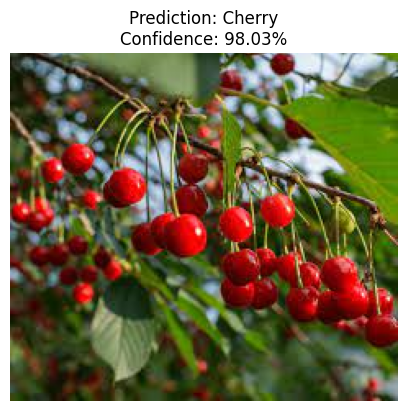

In [98]:
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# ------------------------------------
# Image path
# ------------------------------------
image_path = "../../../Datasets_for_my_practice/agricultural_crops/Agricultural-crops/Cherry/image15.jpeg"

# ------------------------------------
# Load image
# ------------------------------------
image = Image.open(image_path).convert("RGB")

# Show original image
plt.figure(figsize=(5,5))
plt.imshow(image)
plt.axis("off")

# ------------------------------------
# Apply preprocessing
# ------------------------------------
input_tensor = valid_transform(image).unsqueeze(0).to(device)

# ------------------------------------
# Prediction
# ------------------------------------
with torch.no_grad():

    outputs = model(input_tensor)

    probabilities = F.softmax(outputs, dim=1)

    confidence, predicted = torch.max(probabilities, dim=1)

# ------------------------------------
# Get class name
# ------------------------------------
predicted_class = test_dataset.classes[predicted.item()]
confidence = confidence.item() * 100

plt.title(
    f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%"
)

plt.show()